### PyTorch MNIST 手写数字识别快速入门
- 使用两层全连接神经网络实现MNIST手写数字识别
- 包含数据集构建、模型训练和测试的完整流程

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np

In [3]:
# 设置随机种子以确保结果可复现
torch.manual_seed(42)

In [4]:

# ==================== 1. 数据集处理 ====================
print("=" * 50)
print("1. 加载和处理MNIST数据集")
print("=" * 50)

def get_data_loaders(batch_size=64):
    """
    创建训练集和测试集的数据加载器
    
    数据预处理步骤:
    1. 将图像转换为Tensor
    2. 归一化: 使用MNIST数据集的均值(0.1307)和标准差(0.3081)
    """
    # 定义数据变换
    transform = transforms.Compose([
        transforms.ToTensor(),  # 将PIL图像或numpy数组转换为tensor,并将像素值缩放到[0,1]
        transforms.Normalize((0.1307,), (0.3081,))  # 标准化
    ])
    
    # 下载并加载训练集
    train_dataset = datasets.MNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )
    
    # 下载并加载测试集
    test_dataset = datasets.MNIST(
        root='./data',
        train=False,
        download=True,
        transform=transform
    )
    
    # 创建数据加载器
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,  # 训练时打乱数据
        num_workers=2
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,  # 测试时不打乱
        num_workers=2
    )
    
    return train_loader, test_loader

# 创建数据加载器
train_loader, test_loader = get_data_loaders(batch_size=64)

# 查看数据集信息
print(f"训练集大小: {len(train_loader.dataset)} 张图像")
print(f"测试集大小: {len(test_loader.dataset)} 张图像")
print(f"训练批次数: {len(train_loader)}")
print(f"测试批次数: {len(test_loader)}")

# 查看单个batch的数据形状
for images, labels in train_loader:
    print(f"\n数据形状 [N, C, H, W]: {images.shape} {images.dtype}")
    print(f"标签形状: {labels.shape} {labels.dtype}")
    break

1. 加载和处理MNIST数据集
训练集大小: 60000 张图像
测试集大小: 10000 张图像
训练批次数: 938
测试批次数: 157

数据形状 [N, C, H, W]: torch.Size([64, 1, 28, 28]) torch.float32
标签形状: torch.Size([64]) torch.int64



1.1 可视化MNIST数据集样本
训练集样本:


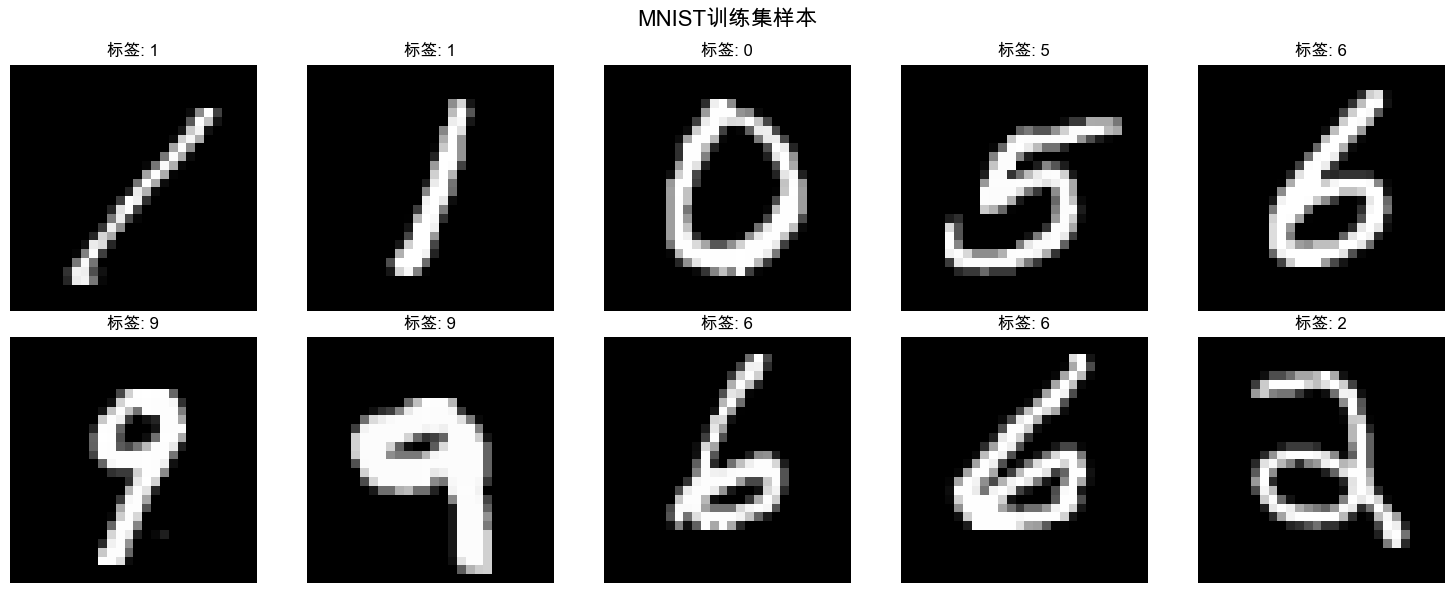


测试集样本:


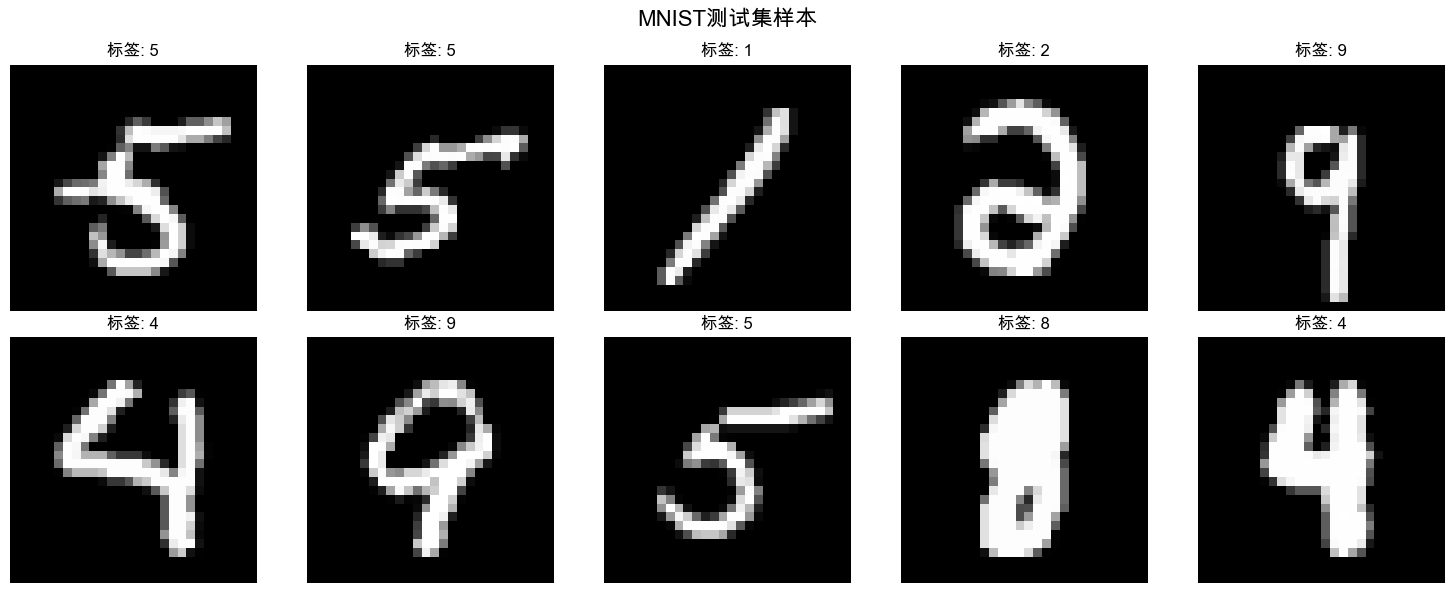


数据集统计信息


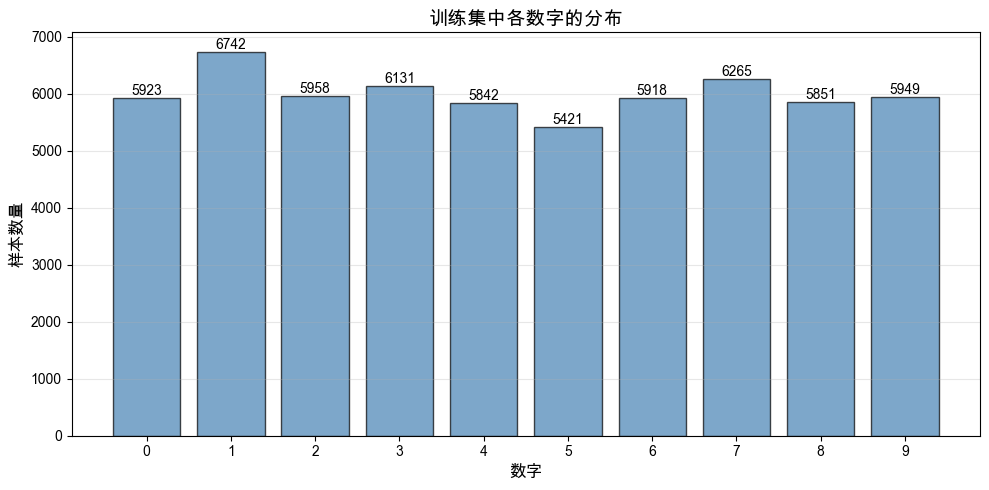


训练集标签分布:
  数字 0:  5923 张 (9.87%)
  数字 1:  6742 张 (11.24%)
  数字 2:  5958 张 (9.93%)
  数字 3:  6131 张 (10.22%)
  数字 4:  5842 张 (9.74%)
  数字 5:  5421 张 (9.04%)
  数字 6:  5918 张 (9.86%)
  数字 7:  6265 张 (10.44%)
  数字 8:  5851 张 (9.75%)
  数字 9:  5949 张 (9.92%)



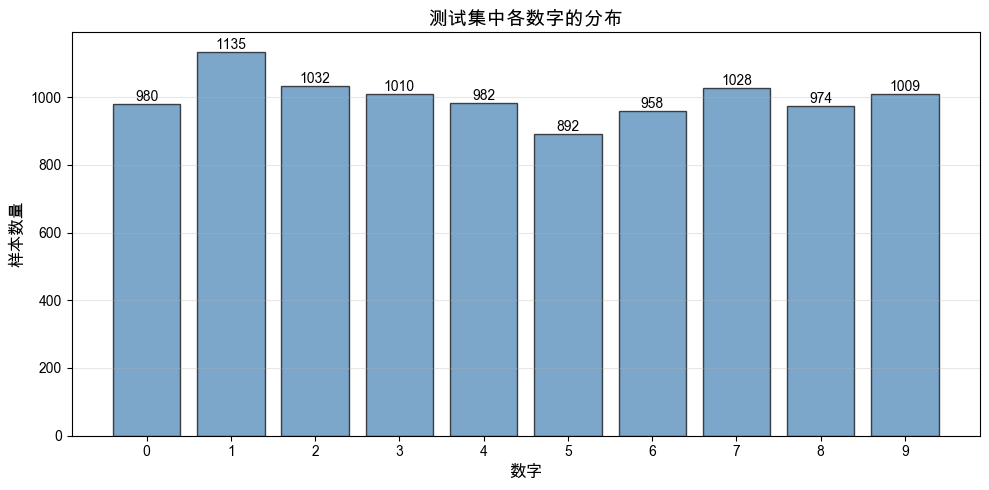


测试集标签分布:
  数字 0:   980 张 (9.80%)
  数字 1:  1135 张 (11.35%)
  数字 2:  1032 张 (10.32%)
  数字 3:  1010 张 (10.10%)
  数字 4:   982 张 (9.82%)
  数字 5:   892 张 (8.92%)
  数字 6:   958 张 (9.58%)
  数字 7:  1028 张 (10.28%)
  数字 8:   974 张 (9.74%)
  数字 9:  1009 张 (10.09%)


In [5]:
# ==================== 1.1 可视化MNIST数据集样本 ====================
print("\n" + "=" * 50)
print("1.1 可视化MNIST数据集样本")
print("=" * 50)

import matplotlib.pyplot as plt

def show_mnist_samples(dataset, num_samples=10, title="MNIST数据集样本"):
    """
    显示MNIST数据集中的样本图片
    
    Args:
        dataset: MNIST数据集
        num_samples: 要显示的样本数量
        title: 图表标题
    """
    # 设置中文字体（如果需要）
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']  # 用来正常显示中文标签
    plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
    
    # 创建子图
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    # 随机选择样本
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    for idx, ax in enumerate(axes.flat):
        # 获取图片和标签
        image, label = dataset[indices[idx]]
        
        # 将tensor转换为numpy数组并去除归一化
        # 由于图片已经归一化，我们需要反归一化以正确显示
        image_np = image.squeeze().numpy()
        
        # 反归一化: x = (x * std) + mean
        image_np = image_np * 0.3081 + 0.1307
        
        # 裁剪到[0, 1]范围
        image_np = np.clip(image_np, 0, 1)
        
        # 显示图片
        ax.imshow(image_np, cmap='gray')
        ax.set_title(f'标签: {label}', fontsize=12, fontweight='bold')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# 显示训练集样本
print("训练集样本:")
show_mnist_samples(train_loader.dataset, num_samples=10, title="MNIST训练集样本")

# 显示测试集样本
print("\n测试集样本:")
show_mnist_samples(test_loader.dataset, num_samples=10, title="MNIST测试集样本")

# 统计各数字的分布
print("\n" + "=" * 50)
print("数据集统计信息")
print("=" * 50)

def show_label_distribution(dataset, dataset_name="数据集"):
    """
    显示数据集中各数字的分布
    """
    labels = [label for _, label in dataset]
    unique, counts = np.unique(labels, return_counts=True)
    
    # 创建柱状图
    plt.figure(figsize=(10, 5))
    bars = plt.bar(unique, counts, color='steelblue', alpha=0.7, edgecolor='black')
    
    # 在柱子上标注数量
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{count}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.xlabel('数字', fontsize=12)
    plt.ylabel('样本数量', fontsize=12)
    plt.title(f'{dataset_name}中各数字的分布', fontsize=14, fontweight='bold')
    plt.xticks(unique)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 打印统计信息
    print(f"\n{dataset_name}标签分布:")
    for digit, count in zip(unique, counts):
        percentage = count / len(labels) * 100
        print(f"  数字 {digit}: {count:>5} 张 ({percentage:.2f}%)")

# 显示训练集分布
show_label_distribution(train_loader.dataset, "训练集")

# 显示测试集分布
print()
show_label_distribution(test_loader.dataset, "测试集")

In [5]:
# ==================== 2. 网络构建 ====================
print("\n" + "=" * 50)
print("2. 构建两层全连接神经网络")
print("=" * 50)

class TwoLayerNet(nn.Module):
    """
    两层全连接神经网络
    
    网络结构:
    - 输入层: 28*28 = 784 个神经元
    - 隐藏层: 512 个神经元 + ReLU激活
    - 输出层: 10 个神经元 (对应0-9十个数字)
    """
    def __init__(self):
        super(TwoLayerNet, self).__init__()
        self.flatten = nn.Flatten()  # 将图像展平为一维向量
        self.fc1 = nn.Linear(28 * 28, 512)  # 第一层全连接
        self.relu = nn.ReLU()  # ReLU激活函数
        self.fc2 = nn.Linear(512, 10)  # 第二层全连接(输出层)
    
    def forward(self, x):
        """
        前向传播
        
        Args:
            x: 输入图像 [batch_size, 1, 28, 28]
        
        Returns:
            logits: 未经过softmax的输出 [batch_size, 10]
        """
        x = self.flatten(x)  # [batch_size, 784]
        x = self.fc1(x)      # [batch_size, 512]
        x = self.relu(x)     # [batch_size, 512]
        logits = self.fc2(x) # [batch_size, 10]
        return logits

# 实例化模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

model = TwoLayerNet().to(device)
print(f"\n模型结构:\n{model}")

# 统计模型参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")


2. 构建两层全连接神经网络
使用设备: cpu

模型结构:
TwoLayerNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)

总参数量: 407,050
可训练参数量: 407,050


In [6]:
# ==================== 3. 模型训练 ====================
print("\n" + "=" * 50)
print("3. 模型训练")
print("=" * 50)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()  # 交叉熵损失函数
optimizer = optim.SGD(model.parameters(), lr=0.01)  # 随机梯度下降优化器

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """
    训练一个epoch
    
    训练步骤:
    1. 正向传播: 计算模型输出和损失
    2. 反向传播: 计算梯度
    3. 参数更新: 使用优化器更新参数
    """
    model.train()  # 设置为训练模式
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        # 将数据移到设备上
        data, target = data.to(device), target.to(device)
        
        # 清零梯度
        optimizer.zero_grad()
        
        # 正向传播
        output = model(data)
        loss = criterion(output, target)
        
        # 反向传播
        loss.backward()
        
        # 参数更新
        optimizer.step()
        
        # 统计
        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)
        
        # 每100个batch打印一次
        if batch_idx % 100 == 0:
            print(f"loss: {loss.item():>7f}  [{batch_idx:>3d}/{len(train_loader):>3d}]")
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

def test(model, test_loader, criterion, device):
    """
    测试模型性能
    """
    model.eval()  # 设置为评估模式
    test_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():  # 测试时不需要计算梯度
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
    
    avg_loss = test_loss / len(test_loader)
    accuracy = 100. * correct / total
    
    print(f"Test: \n Accuracy: {accuracy:>0.1f}%, Avg loss: {avg_loss:>8f} \n")
    return avg_loss, accuracy

# 训练模型
epochs = 3
print(f"开始训练，共 {epochs} 个epoch\n")

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}")
    print("-" * 50)
    
    # 训练
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # 测试
    test_loss, test_acc = test(model, test_loader, criterion, device)

print("训练完成!")


3. 模型训练
开始训练，共 3 个epoch

Epoch 1
--------------------------------------------------
loss: 2.317252  [  0/938]
loss: 0.878381  [100/938]
loss: 0.627652  [200/938]
loss: 0.469564  [300/938]
loss: 0.523874  [400/938]
loss: 0.377622  [500/938]
loss: 0.366340  [600/938]
loss: 0.288233  [700/938]
loss: 0.272867  [800/938]
loss: 0.280056  [900/938]
Test: 
 Accuracy: 91.5%, Avg loss: 0.307020 

Epoch 2
--------------------------------------------------
loss: 0.345747  [  0/938]
loss: 0.367210  [100/938]
loss: 0.265120  [200/938]
loss: 0.205100  [300/938]
loss: 0.317305  [400/938]
loss: 0.169915  [500/938]
loss: 0.223994  [600/938]
loss: 0.180566  [700/938]
loss: 0.278126  [800/938]
loss: 0.108670  [900/938]
Test: 
 Accuracy: 93.1%, Avg loss: 0.246776 

Epoch 3
--------------------------------------------------
loss: 0.453348  [  0/938]
loss: 0.377049  [100/938]
loss: 0.139048  [200/938]
loss: 0.336053  [300/938]
loss: 0.166334  [400/938]
loss: 0.149095  [500/938]
loss: 0.166542  [600/938]
los

In [7]:

# ==================== 4. 保存模型 ====================
print("\n" + "=" * 50)
print("4. 保存模型")
print("=" * 50)

# 保存完整模型
torch.save(model.state_dict(), 'mnist_model.pth')
print("模型已保存到 mnist_model.pth")




4. 保存模型
模型已保存到 mnist_model.pth


In [8]:
# ==================== 5. 加载模型并预测 ====================
print("\n" + "=" * 50)
print("5. 加载模型并进行预测")
print("=" * 50)

# 重新实例化模型
loaded_model = TwoLayerNet().to(device)

# 加载模型参数
loaded_model.load_state_dict(torch.load('mnist_model.pth'))
print("模型参数加载成功")

# 使用加载的模型进行预测
loaded_model.eval()
with torch.no_grad():
    for data, label in test_loader:
        data = data.to(device)
        output = loaded_model(data)
        predicted = output.argmax(dim=1)
        
        # 打印前10个预测结果
        print(f'预测结果: {predicted[:10].cpu().numpy()}')
        print(f'真实标签: {label[:10].numpy()}')
        break

print("\n" + "=" * 50)
print("完成!")
print("=" * 50)


5. 加载模型并进行预测
模型参数加载成功


/var/folders/xp/y_f9g_n51n96bs3m6d4d6ztr0000gn/T/ipykernel_24409/2507488971.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('mni

预测结果: [7 2 1 0 4 1 4 9 6 9]
真实标签: [7 2 1 0 4 1 4 9 5 9]

完成!
